# Total Fixations (Overall) Analysis


## Preprocessing
Required Imports

In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Useful functions

In [14]:
def filter_by_polarity(df):
    '''
    Function to filter the DataFrame by polarity (claro and oscuro)

    There must be a column named Timeline with the values 'Timeline1-Mode1' for claro and 'Timeline2-Mode2' for oscuro
    '''
    claro = df[df['Timeline'] == 'Timeline1-Mode1'] 
    oscuro = df[df['Timeline'] == 'Timeline2-Mode2'] 
    return claro, oscuro

def obtain_basic_data(array):
    mean = np.mean(array)
    
    std = np.std(array)
    max = np.max(array)
    min = np.min(array)
    return mean, std, max, min

def separate_by_toi(df, toi):
    '''
    Function to obtain Patata, Mochila, Text and Entire Recording

    There must be a column named 'TOI' 
    '''
    df_toi = df[df['TOI'] == toi]
    return df_toi

First Pandas dataset

In [15]:
tf = pd.read_csv('raw/TotalFixations.tsv', sep='\t')

tf_claro, tf_oscuro = filter_by_polarity(tf)


tf_claro_patata = separate_by_toi(tf_claro, 'PatataClaro')
tf_oscuro_patata = separate_by_toi(tf_oscuro, 'PatataOscuro')

tf_claro_mochila = separate_by_toi(tf_claro, 'MochilaClaro')
tf_oscuro_mochila = separate_by_toi(tf_oscuro, 'MochilaOscuro')

tf_claro_entire = separate_by_toi(tf_claro, 'Entire Recording')
tf_oscuro_entire = separate_by_toi(tf_oscuro, 'Entire Recording')

def run_function_on_totalfixations(df, func):
    '''Runs the given function on the specified columns of the dataframe'''
    return func(df['Total_duration_of_whole_fixations']),func(df['Number_of_whole_fixations']),func(df['Duration_of_first_whole_fixation']),func(df['Average_duration_of_whole_fixations'])


## Processing
### Basics

In [16]:
basic_data = {
    'PatataClaro': run_function_on_totalfixations(tf_claro_patata, obtain_basic_data),
    'PatataOscuro': run_function_on_totalfixations(tf_oscuro_patata, obtain_basic_data),
    'MochilaClaro': run_function_on_totalfixations(tf_claro_mochila, obtain_basic_data),
    'MochilaOscuro': run_function_on_totalfixations(tf_oscuro_mochila, obtain_basic_data),
    'EntireClaro': run_function_on_totalfixations(tf_claro_entire, obtain_basic_data),
    'EntireOscuro': run_function_on_totalfixations(tf_oscuro_entire, obtain_basic_data),
}
def basic_data_to_string(basic_data):
    return " - [Mean: {:.2f}] [Std: {:.2f}] [Max: {:.2f}] [Min: {:.2f}]".format(*basic_data)
    
for key in basic_data:
    print(f"Results for {key}:")
    print("Total_duration_of_whole_fixations", basic_data_to_string(basic_data[key][0]))
    print("Number_of_whole_fixations", basic_data_to_string(basic_data[key][1]))
    print("Duration_of_first_whole_fixation", basic_data_to_string(basic_data[key][2]))
    print("Average_duration_of_whole_fixations", basic_data_to_string(basic_data[key][3]))
    print()

Results for PatataClaro:
Total_duration_of_whole_fixations  - [Mean: 52902.88] [Std: 24410.26] [Max: 125026.00] [Min: 18570.00]
Number_of_whole_fixations  - [Mean: 158.94] [Std: 52.41] [Max: 301.00] [Min: 62.00]
Duration_of_first_whole_fixation  - [Mean: 181.29] [Std: 111.99] [Max: 583.00] [Min: 83.00]
Average_duration_of_whole_fixations  - [Mean: 329.29] [Std: 79.39] [Max: 537.00] [Min: 234.00]

Results for PatataOscuro:
Total_duration_of_whole_fixations  - [Mean: 41879.59] [Std: 17204.72] [Max: 72631.00] [Min: 2631.00]
Number_of_whole_fixations  - [Mean: 142.65] [Std: 50.59] [Max: 208.00] [Min: 13.00]
Duration_of_first_whole_fixation  - [Mean: 205.82] [Std: 100.07] [Max: 533.00] [Min: 100.00]
Average_duration_of_whole_fixations  - [Mean: 287.53] [Std: 57.97] [Max: 441.00] [Min: 202.00]

Results for MochilaClaro:
Total_duration_of_whole_fixations  - [Mean: 64217.12] [Std: 34024.20] [Max: 125642.00] [Min: 9443.00]
Number_of_whole_fixations  - [Mean: 199.06] [Std: 92.76] [Max: 320.00] [

## T-student analysis

In [17]:
def ttest_independent_samples(df1, df2):
    return {"Total_duration_of_whole_fixations": stats.ttest_ind(df1['Total_duration_of_whole_fixations'], df2['Total_duration_of_whole_fixations'], equal_var=False),
            "Number_of_whole_fixations": stats.ttest_ind(df1['Number_of_whole_fixations'], df2['Number_of_whole_fixations'], equal_var=False),
            "Duration_of_first_whole_fixation": stats.ttest_ind(df1['Duration_of_first_whole_fixation'], df2['Duration_of_first_whole_fixation'], equal_var=False),
            "Average_duration_of_whole_fixations": stats.ttest_ind(df1['Average_duration_of_whole_fixations'], df2['Average_duration_of_whole_fixations'], equal_var=False)}



tf_patata_tstudent = ttest_independent_samples(tf_claro_patata, tf_oscuro_patata)
tf_mochila_tstudent = ttest_independent_samples(tf_claro_mochila, tf_oscuro_mochila)
tf_entire_tstudent = ttest_independent_samples(tf_claro_entire, tf_oscuro_entire)

print("T-Student Patata Results:")
for key in tf_patata_tstudent:
    print(f"{key}: t-statistic = {tf_patata_tstudent[key].statistic:.4f}, p-value = {tf_patata_tstudent[key].pvalue:.4f}")
print()

print("T-Student Mochila Results:")
for key in tf_mochila_tstudent:
    print(f"{key}: t-statistic = {tf_mochila_tstudent[key].statistic:.4f}, p-value = {tf_mochila_tstudent[key].pvalue:.4f}")
print()
print("T-Student Entire Recording Results:")
for key in tf_entire_tstudent:
    print(f"{key}: t-statistic = {tf_entire_tstudent[key].statistic:.4f}, p-value = {tf_entire_tstudent[key].pvalue:.4f}")
print()

T-Student Patata Results:
Total_duration_of_whole_fixations: t-statistic = 1.4765, p-value = 0.1507
Number_of_whole_fixations: t-statistic = 0.8947, p-value = 0.3776
Duration_of_first_whole_fixation: t-statistic = -0.6533, p-value = 0.5183
Average_duration_of_whole_fixations: t-statistic = 1.6994, p-value = 0.0998

T-Student Mochila Results:
Total_duration_of_whole_fixations: t-statistic = 1.0032, p-value = 0.3244
Number_of_whole_fixations: t-statistic = 0.1791, p-value = 0.8591
Duration_of_first_whole_fixation: t-statistic = -0.2076, p-value = 0.8374
Average_duration_of_whole_fixations: t-statistic = 2.1353, p-value = 0.0405

T-Student Entire Recording Results:
Total_duration_of_whole_fixations: t-statistic = 2.5175, p-value = 0.0174
Number_of_whole_fixations: t-statistic = 1.8583, p-value = 0.0736
Duration_of_first_whole_fixation: t-statistic = 1.4192, p-value = 0.1675
Average_duration_of_whole_fixations: t-statistic = 1.4303, p-value = 0.1624



Matplotlib results shown

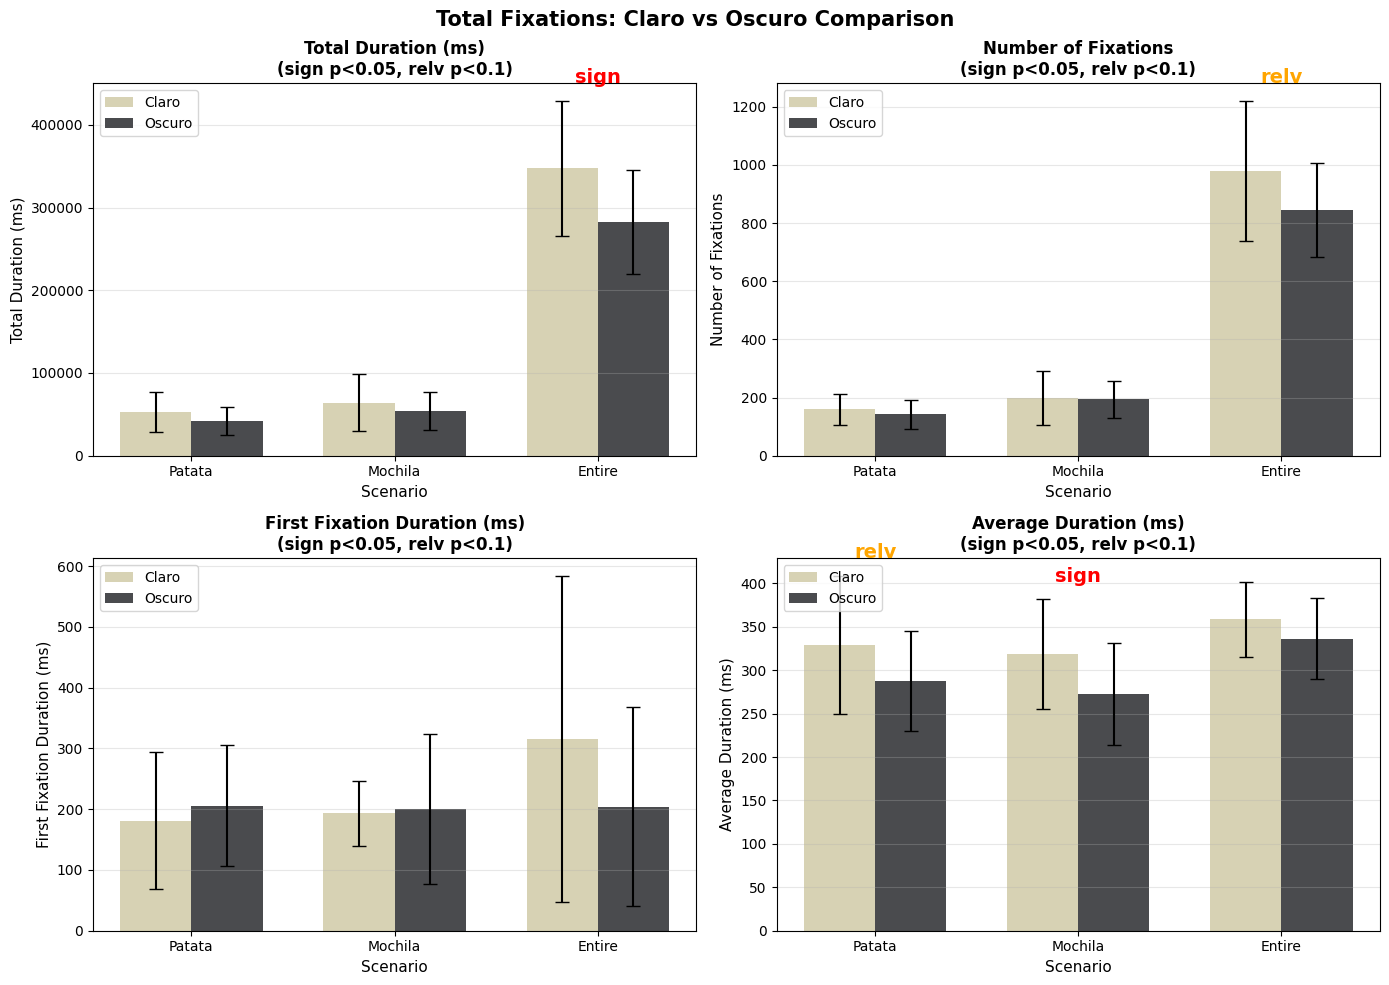

In [18]:

# Github Copilot + some edits from myself from here
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Labels NOTA: Para proximas usar un array como metrics en vez de lo que hago en las lambda
metrics = ['Total_duration_of_whole_fixations', 'Number_of_whole_fixations', 
           'Duration_of_first_whole_fixation', 'Average_duration_of_whole_fixations']
metric_labels = ['Total Duration (ms)', 'Number of Fixations', 
                 'First Fixation Duration (ms)', 'Average Duration (ms)']
toi_labels = ['Patata', 'Mochila', 'Entire']


tstudent_data = [tf_patata_tstudent, tf_mochila_tstudent, tf_entire_tstudent]


for idx, metric in enumerate(metrics):
    ax = axes[idx]
    

    claro_means = [basic_data['PatataClaro'][idx][0], 
                   basic_data['MochilaClaro'][idx][0], 
                   basic_data['EntireClaro'][idx][0]]
    claro_stds = [basic_data['PatataClaro'][idx][1], 
                  basic_data['MochilaClaro'][idx][1], 
                  basic_data['EntireClaro'][idx][1]]
    oscuro_means = [basic_data['PatataOscuro'][idx][0], 
                    basic_data['MochilaOscuro'][idx][0], 
                    basic_data['EntireOscuro'][idx][0]]
    oscuro_stds = [basic_data['PatataOscuro'][idx][1], 
                   basic_data['MochilaOscuro'][idx][1], 
                   basic_data['EntireOscuro'][idx][1]]
    
    x = np.arange(len(toi_labels))
    width = 0.35
    
    # Create bars with error bars
    bars1 = ax.bar(x - width/2, claro_means, width, yerr=claro_stds, 
                   label='Claro', color="#CEC7A2", alpha=0.8, capsize=5)
    bars2 = ax.bar(x + width/2, oscuro_means, width, yerr=oscuro_stds, 
                   label='Oscuro', color="#1D1E22", alpha=0.8, capsize=5)
    
    # Add significance markers
    for j, toi_label in enumerate(toi_labels):
        pvalue = tstudent_data[j][metric].pvalue
        if pvalue < 0.05:
            # Add significance star
            y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])
            ax.text(x[j], y_pos * 1.05, 'sign', ha='center', fontsize=14, fontweight='bold', color='red')
        elif pvalue < 0.1:
            y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])
            ax.text(x[j], y_pos * 1.05, 'relv', ha='center', fontsize=14, fontweight='bold', color='orange')
    
    ax.set_xlabel('Scenario', fontsize=11)
    ax.set_ylabel(metric_labels[idx], fontsize=11)
    ax.set_title(f'{metric_labels[idx]}\n(sign p<0.05, relv p<0.1)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(toi_labels)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Total Fixations: Claro vs Oscuro Comparison', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# END OF GH COPILOT

# Saccades Analysis

In [19]:
sf = pd.read_csv('raw/Saccades.tsv', sep='\t')

metrics = ['Average_peak_velocity_of_saccades', 'Average_amplitude_of_saccades', 'Number_of_saccades']

sf['Average_peak_velocity_of_saccades'] = sf['Average_peak_velocity_of_saccades'].str.replace(',', '.').astype(float)
sf['Average_amplitude_of_saccades'] = sf['Average_amplitude_of_saccades'].str.replace(',', '.').astype(float)

sf_claro, sf_oscuro = filter_by_polarity(sf)

sf_claro_patata = separate_by_toi(sf_claro, 'PatataClaro')
sf_oscuro_patata = separate_by_toi(sf_oscuro, 'PatataOscuro')

sf_claro_mochila = separate_by_toi(sf_claro, 'MochilaClaro')
sf_oscuro_mochila = separate_by_toi(sf_oscuro, 'MochilaOscuro')

sf_claro_entire = separate_by_toi(sf_claro, 'Entire Recording')
sf_oscuro_entire = separate_by_toi(sf_oscuro, 'Entire Recording')

def run_function_on_dataframe(df, func,params):
    '''Runs the given function on the specified columns of the dataframe'''
    aux = []
    for param in params:
        aux.append(func(df[param]))
    return aux

## Processing
### Basics

In [20]:
basic_data_saccades = {
    'PatataClaro': run_function_on_dataframe(sf_claro_patata, obtain_basic_data, metrics),
    'PatataOscuro': run_function_on_dataframe(sf_oscuro_patata, obtain_basic_data, metrics),
    'MochilaClaro': run_function_on_dataframe(sf_claro_mochila, obtain_basic_data, metrics),
    'MochilaOscuro': run_function_on_dataframe(sf_oscuro_mochila, obtain_basic_data, metrics),
    'EntireClaro': run_function_on_dataframe(sf_claro_entire, obtain_basic_data, metrics),
    'EntireOscuro': run_function_on_dataframe(sf_oscuro_entire, obtain_basic_data, metrics),
}

for key in basic_data_saccades:
    print(f"Results for {key}:")
    print("Average_peak_velocity_of_saccades", basic_data_to_string(basic_data_saccades[key][0]))
    print("Average_amplitude_of_saccades", basic_data_to_string(basic_data_saccades[key][1]))
    print("Number_of_saccades", basic_data_to_string(basic_data_saccades[key][2]))
    print() 

Results for PatataClaro:
Average_peak_velocity_of_saccades  - [Mean: 107.76] [Std: 15.84] [Max: 148.82] [Min: 89.13]
Average_amplitude_of_saccades  - [Mean: 2.97] [Std: 0.48] [Max: 3.87] [Min: 2.22]
Number_of_saccades  - [Mean: 151.29] [Std: 47.86] [Max: 270.00] [Min: 59.00]

Results for PatataOscuro:
Average_peak_velocity_of_saccades  - [Mean: 118.72] [Std: 29.61] [Max: 216.31] [Min: 79.57]
Average_amplitude_of_saccades  - [Mean: 3.26] [Std: 0.69] [Max: 5.30] [Min: 2.26]
Number_of_saccades  - [Mean: 134.41] [Std: 50.24] [Max: 199.00] [Min: 13.00]

Results for MochilaClaro:
Average_peak_velocity_of_saccades  - [Mean: 102.25] [Std: 24.92] [Max: 189.92] [Min: 77.19]
Average_amplitude_of_saccades  - [Mean: 2.95] [Std: 0.70] [Max: 5.15] [Min: 1.92]
Number_of_saccades  - [Mean: 184.18] [Std: 83.67] [Max: 305.00] [Min: 34.00]

Results for MochilaOscuro:
Average_peak_velocity_of_saccades  - [Mean: 104.02] [Std: 16.63] [Max: 133.35] [Min: 76.66]
Average_amplitude_of_saccades  - [Mean: 2.98] [S

## T-student analysis

In [21]:
def ttest_independent_samples_saccades(df1, df2):
    return {"Average_peak_velocity_of_saccades": stats.ttest_ind(df1['Average_peak_velocity_of_saccades'], df2['Average_peak_velocity_of_saccades'], equal_var=False),
            "Average_amplitude_of_saccades": stats.ttest_ind(df1['Average_amplitude_of_saccades'], df2['Average_amplitude_of_saccades'], equal_var=False),
            "Number_of_saccades": stats.ttest_ind(df1['Number_of_saccades'], df2['Number_of_saccades'], equal_var=False)}


sf_patata_tstudent = ttest_independent_samples_saccades(sf_claro_patata, sf_oscuro_patata)
sf_mochila_tstudent = ttest_independent_samples_saccades(sf_claro_mochila, sf_oscuro_mochila)
sf_entire_tstudent = ttest_independent_samples_saccades(sf_claro_entire, sf_oscuro_entire)

print("T-Student Patata Results:")
for key in sf_patata_tstudent:
    print(f"{key}: t-statistic = {sf_patata_tstudent[key].statistic:.4f}, p-value = {sf_patata_tstudent[key].pvalue:.4f}")
print()

print("T-Student Mochila Results:")
for key in sf_mochila_tstudent:
    print(f"{key}: t-statistic = {sf_mochila_tstudent[key].statistic:.4f}, p-value = {sf_mochila_tstudent[key].pvalue:.4f}")
print()

print("T-Student Entire Recording Results:")
for key in sf_entire_tstudent:
    print(f"{key}: t-statistic = {sf_entire_tstudent[key].statistic:.4f}, p-value = {sf_entire_tstudent[key].pvalue:.4f}")
print()

T-Student Patata Results:
Average_peak_velocity_of_saccades: t-statistic = -1.3058, p-value = 0.2038
Average_amplitude_of_saccades: t-statistic = -1.3636, p-value = 0.1833
Number_of_saccades: t-statistic = 0.9733, p-value = 0.3377

T-Student Mochila Results:
Average_peak_velocity_of_saccades: t-statistic = -0.2360, p-value = 0.8152
Average_amplitude_of_saccades: t-statistic = -0.1143, p-value = 0.9098
Number_of_saccades: t-statistic = 0.4961, p-value = 0.6236

T-Student Entire Recording Results:
Average_peak_velocity_of_saccades: t-statistic = -1.7772, p-value = 0.0871
Average_amplitude_of_saccades: t-statistic = -1.4317, p-value = 0.1620
Number_of_saccades: t-statistic = 1.9661, p-value = 0.0582



Matplotlib results shown

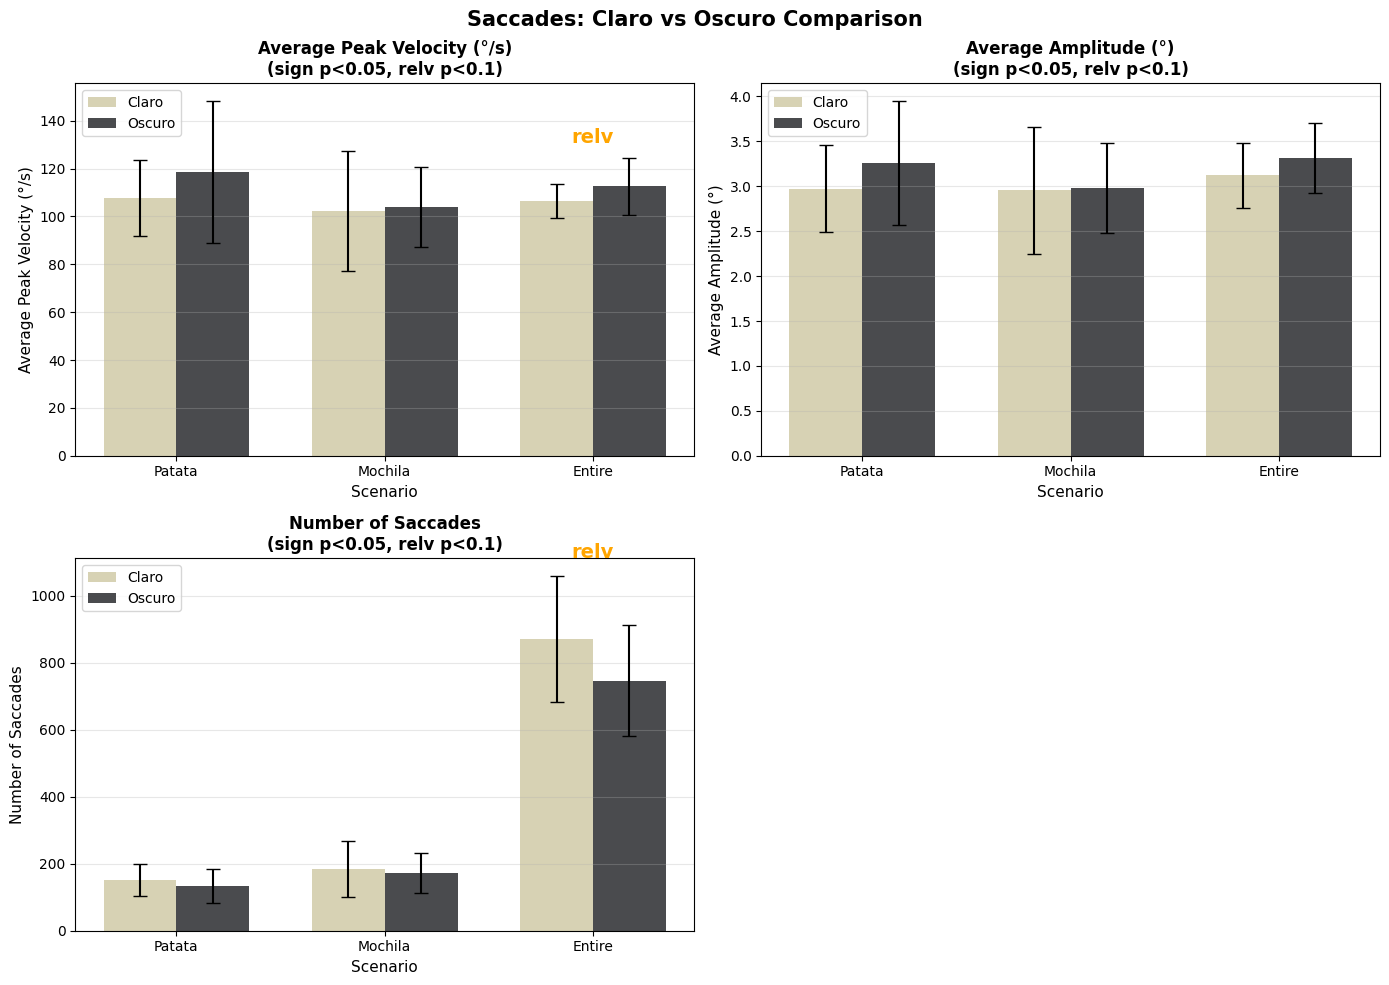

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()


metric_labels = ['Average Peak Velocity (°/s)', 'Average Amplitude (°)', 'Number of Saccades']
toi_labels = ['Patata', 'Mochila', 'Entire']

tstudent_data_saccades = [sf_patata_tstudent, sf_mochila_tstudent, sf_entire_tstudent]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    claro_means = [basic_data_saccades['PatataClaro'][idx][0], 
                   basic_data_saccades['MochilaClaro'][idx][0], 
                   basic_data_saccades['EntireClaro'][idx][0]]
    claro_stds = [basic_data_saccades['PatataClaro'][idx][1], 
                  basic_data_saccades['MochilaClaro'][idx][1], 
                  basic_data_saccades['EntireClaro'][idx][1]]
    oscuro_means = [basic_data_saccades['PatataOscuro'][idx][0], 
                    basic_data_saccades['MochilaOscuro'][idx][0], 
                    basic_data_saccades['EntireOscuro'][idx][0]]
    oscuro_stds = [basic_data_saccades['PatataOscuro'][idx][1], 
                   basic_data_saccades['MochilaOscuro'][idx][1], 
                   basic_data_saccades['EntireOscuro'][idx][1]]
    
    x = np.arange(len(toi_labels))
    width = 0.35
    
    # Create bars with error bars
    bars1 = ax.bar(x - width/2, claro_means, width, yerr=claro_stds, 
                   label='Claro', color="#CEC7A2", alpha=0.8, capsize=5)
    bars2 = ax.bar(x + width/2, oscuro_means, width, yerr=oscuro_stds, 
                   label='Oscuro', color="#1D1E22", alpha=0.8, capsize=5)
    
    # Add significance markers
    for j, toi_label in enumerate(toi_labels):
        pvalue = tstudent_data_saccades[j][metric].pvalue
        if pvalue < 0.05:
            # Add significance star
            y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])
            ax.text(x[j], y_pos * 1.05, 'sign', ha='center', fontsize=14, fontweight='bold', color='red')
        elif pvalue < 0.1:
            y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])
            ax.text(x[j], y_pos * 1.05, 'relv', ha='center', fontsize=14, fontweight='bold', color='orange')
    
    ax.set_xlabel('Scenario', fontsize=11)
    ax.set_ylabel(metric_labels[idx], fontsize=11)
    ax.set_title(f'{metric_labels[idx]}\n(sign p<0.05, relv p<0.1)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(toi_labels)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

# Hide the 4th subplot since we only have 3 metrics
axes[3].set_visible(False)

plt.suptitle('Saccades: Claro vs Oscuro Comparison', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()